In [ ]:
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import grcwa
except Exception as e:
    raise ImportError(
        "grcwa is required. Install with: pip install grcwa"
    ) from e

# Approximate optical constants of Au across visible/NIR.
_AU_WL_NM = np.array(
    [400, 450, 500, 550, 600, 650, 700, 750, 800, 900, 1000, 1100],
    dtype=float,
    )
UNIT_CELL_INPUT = {
    **UNIT_CELL_PRESETS["square"],  # change to ["hex"] to try the hexagonal/triangular cell
    "wavelength_min": 550e-9,
    "wavelength_max": 700e-9,
    "wavelength_step": 25e-9,
    "harmonics_xy": (5, 5),
    "grid_nx": 61,
    "grid_ny": 61,
    "out_prefix": "rcwa_current_unit_cell",
    "make_plots": True,
    "save_outputs": True,
}
,

## Unit Cell Input Block
Edit this block to try different unit cells without changing the solver code below. Use one of the presets, then override any values you want for the current run.

In [4]:
from matplotlib.patches import Circle, Polygon

def plot_unit_cell_schematic(
    cfg: SimConfig,
    out_prefix: str | None = None,
    show: bool = True,
    ) -> str:
    lat_list = primitive_vectors(cfg.lattice, cfg.period)
    a1 = np.array(lat_list[0], dtype=float)
    a2 = np.array(lat_list[1], dtype=float)
    origin = np.array([0.0, 0.0])
    corners = np.array([
        origin,
        a1,
        a1 + a2,
        a2,
    ])
    center = 0.5 * (a1 + a2)
    radius = 0.5 * cfg.rod_diameter

    fig, ax = plt.subplots(figsize=(6, 6))
    cell_patch = Polygon(corners, closed=True, fill=False, edgecolor="black", linewidth=2.0)
    rod_patch = Circle(center, radius=radius, facecolor="goldenrod", edgecolor="black", alpha=0.7)
    ax.add_patch(cell_patch)
    ax.add_patch(rod_patch)

    ax.annotate("", xy=a1, xytext=origin, arrowprops=dict(arrowstyle="->", lw=2, color="tab:blue"))
    ax.annotate("", xy=a2, xytext=origin, arrowprops=dict(arrowstyle="->", lw=2, color="tab:green"))
    ax.text(*(a1 * 1.04), "a1", color="tab:blue")
    ax.text(*(a2 * 1.04), "a2", color="tab:green")

    pad = max(cfg.period, cfg.rod_diameter) * 0.25
    xmin = np.min(corners[:, 0]) - pad
    xmax = np.max(corners[:, 0]) + pad
    ymin = np.min(corners[:, 1]) - pad
    ymax = np.max(corners[:, 1]) + pad
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(
        f"Unit cell schematic: {cfg.lattice}\n"
        f"period={cfg.period*1e9:.1f} nm, diameter={cfg.rod_diameter*1e9:.1f} nm, height={cfg.rod_height*1e9:.1f} nm"
    )
    ax.grid(alpha=0.25)
    plt.tight_layout()

    prefix = out_prefix if out_prefix is not None else cfg.out_prefix
    file_path = f"{prefix}_unit_cell_schematic.png"
    plt.savefig(file_path, dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return file_path

In [5]:
def sweep_diameter_all_orders(
    lattice: str = "square",
    rod_height: float = 150e-9,
    diameters: np.ndarray = np.arange(50e-9, 201e-9, 10e-9),
    wavelength: float = 633e-9,
    period: float = 500e-9,
    out_prefix: str = "rcwa_diameter_sweep_all_orders",
    phase_amplitude_threshold: float = 1e-8,
    **kwargs,
    ) -> Dict[str, Any]:
    """Sweep rod diameter at a fixed wavelength and keep all propagating orders.

    The returned and saved phase comes from the complex transmission/reflection
    coefficients, not from power efficiencies. Phase is unwrapped along the
    diameter axis separately for each diffraction order.
    """
    all_rows = []
    for diameter in np.asarray(diameters, dtype=float):
        res = simulate(
            lattice=lattice,
            rod_height=rod_height,
            rod_diameter=float(diameter),
            period=period,
            wavelength_min=wavelength,
            wavelength_max=wavelength,
            wavelength_step=wavelength,
            phase_amplitude_threshold=phase_amplitude_threshold,
            make_plots=False,
            save_outputs=False,
            **kwargs,
        )
        df = res["orders_propagating"].copy()
        df["diameter_nm"] = diameter * 1e9
        all_rows.append(df)

    df = pd.concat(all_rows, ignore_index=True)
    df = df.sort_values(["m", "n", "diameter_nm"]).reset_index(drop=True)

    # Unwrap transmission and reflection phase separately along diameter for each order.
    def _unwrap_group(group: pd.DataFrame, phase_col: str, amp_col: str, out_col: str) -> None:
        phase = group[phase_col].to_numpy(dtype=float)
        amp = group[amp_col].to_numpy(dtype=float)
        valid = np.isfinite(phase) & np.isfinite(amp) & (amp >= phase_amplitude_threshold)
        unwrapped = np.full(len(group), np.nan, dtype=float)
        if np.any(valid):
            unwrapped[valid] = np.unwrap(phase[valid])
        df.loc[group.index, out_col] = unwrapped

    df["transmission_phase_unwrapped_deg_diam"] = np.nan
    df["reflection_phase_unwrapped_deg_diam"] = np.nan
    for _, group in df.groupby(["m", "n"], sort=False):
        group = group.sort_values("diameter_nm")
        _unwrap_group(group, "transmission_phase_rad", "transmission_amplitude", "transmission_phase_unwrapped_rad_diam")
        _unwrap_group(group, "reflection_phase_rad", "reflection_amplitude", "reflection_phase_unwrapped_rad_diam")

    df["transmission_phase_unwrapped_deg_diam"] = np.rad2deg(df["transmission_phase_unwrapped_rad_diam"])
    df["reflection_phase_unwrapped_deg_diam"] = np.rad2deg(df["reflection_phase_unwrapped_rad_diam"])

    csv_path = f"{out_prefix}.csv"
    df.to_csv(csv_path, index=False)

    # Heatmaps: one row per diffraction order, one column per diameter.
    order_index = (
        df[["m", "n"]].drop_duplicates().sort_values(["m", "n"]).reset_index(drop=True)
    )
    order_labels = [f"({int(row.m)},{int(row.n)})" for row in order_index.itertuples(index=False)]
    diameter_values = np.sort(df["diameter_nm"].unique())

    T_map = np.full((len(order_labels), len(diameter_values)), np.nan, dtype=float)
    phase_map = np.full((len(order_labels), len(diameter_values)), np.nan, dtype=float)
    amp_map = np.full((len(order_labels), len(diameter_values)), np.nan, dtype=float)

    order_to_row = {(int(row.m), int(row.n)): idx for idx, row in enumerate(order_index.itertuples(index=False))}
    diam_to_col = {float(d): idx for idx, d in enumerate(diameter_values)}

    for _, row in df.iterrows():
        r = order_to_row[(int(row["m"]), int(row["n"]))]
        c = diam_to_col[float(row["diameter_nm"])]
        T_map[r, c] = float(row["T_mn"])
        amp_map[r, c] = float(row["transmission_amplitude"])
        phase_map[r, c] = float(row["transmission_phase_unwrapped_deg_diam"])

    fig_T = f"{out_prefix}_Tmn_vs_diameter.png"
    fig_amp = f"{out_prefix}_amplitude_vs_diameter.png"
    fig_phase = f"{out_prefix}_phase_vs_diameter.png"

    def _heatmap(data: np.ndarray, title: str, ylabel: str, file_path: str, cbar_label: str):
        plt.figure(figsize=(max(10, len(diameter_values) * 0.35), max(6, len(order_labels) * 0.25)))
        plt.imshow(data, aspect="auto", origin="lower")
        plt.colorbar(label=cbar_label)
        plt.xticks(np.arange(len(diameter_values)), [f"{d:.0f}" for d in diameter_values], rotation=90)
        plt.yticks(np.arange(len(order_labels)), order_labels)
        plt.xlabel("Rod diameter (nm)")
        plt.ylabel("Diffraction order (m,n)")
        plt.title(title)
        plt.tight_layout()
        plt.savefig(file_path, dpi=150)
        plt.show()

    _heatmap(T_map, f"Transmission efficiency by order at {wavelength*1e9:.0f} nm", "Diffraction order (m,n)", fig_T, "T_mn")
    _heatmap(amp_map, f"Transmission amplitude by order at {wavelength*1e9:.0f} nm", "Diffraction order (m,n)", fig_amp, "|t_mn|")
    _heatmap(phase_map, f"Transmission phase by order at {wavelength*1e9:.0f} nm", "Diffraction order (m,n)", fig_phase, "phase (deg)")

    # Zeroth-order summary table for metalens use.
    t00 = df[(df["m"] == 0) & (df["n"] == 0)].copy().sort_values("diameter_nm")
    t00 = t00[[
        "diameter_nm",
        "T_mn",
        "transmission_amplitude",
        "transmission_phase_deg",
        "transmission_phase_unwrapped_deg_diam",
    ]].rename(columns={
        "T_mn": "T00",
        "transmission_amplitude": "amplitude_T00",
        "transmission_phase_deg": "phase_T00_deg",
        "transmission_phase_unwrapped_deg_diam": "phase_T00_unwrapped_deg",
    })

    files = {
        "csv": csv_path,
        "fig_Tmn": fig_T,
        "fig_amplitude": fig_amp,
        "fig_phase": fig_phase,
    }

    return {
        "table": df,
        "t00": t00,
        "files": files,
        "diameters_nm": diameter_values,
        "order_labels": order_labels,
    }

In [14]:
UNIT_CELL_PRESETS = {
    "square": {
        "lattice": "square",
        "period": 500e-9,
        "rod_height": 150e-9,
        "rod_diameter": 100e-9,
    },
    "hex": {
        "lattice": "hex",
        "period": 500e-9,
        "rod_height": 150e-9,
        "rod_diameter": 100e-9,
    },
}

# Edit this block to test different unit cells.
# Choose one preset and override any value you want.
UNIT_CELL_INPUT = {
    **UNIT_CELL_PRESETS["hex"],
    # To switch to hexagonal/triangular use: **UNIT_CELL_PRESETS["hex"],
    "lattice": "hex",
    "period": 500e-9,
    "rod_height": 150e-9,
    "rod_diameter": 100e-9,
    "wavelength_min": 550e-9,
    "wavelength_max": 700e-9,
    "wavelength_step": 25e-9,
    "harmonics_xy": (5, 5),
    "grid_nx": 61,
    "grid_ny": 61,
    "out_prefix": "rcwa_current_unit_cell",
    "make_plots": True,
    "save_outputs": True,
}

def run_unit_cell_from_input(user_input: Dict[str, Any]) -> Dict[str, Any]:
    params = dict(user_input)
    lattice = params.pop("lattice")
    rod_height = params.pop("rod_height")
    rod_diameter = params.pop("rod_diameter")
    return simulate(lattice=lattice, rod_height=rod_height, rod_diameter=rod_diameter, **params)

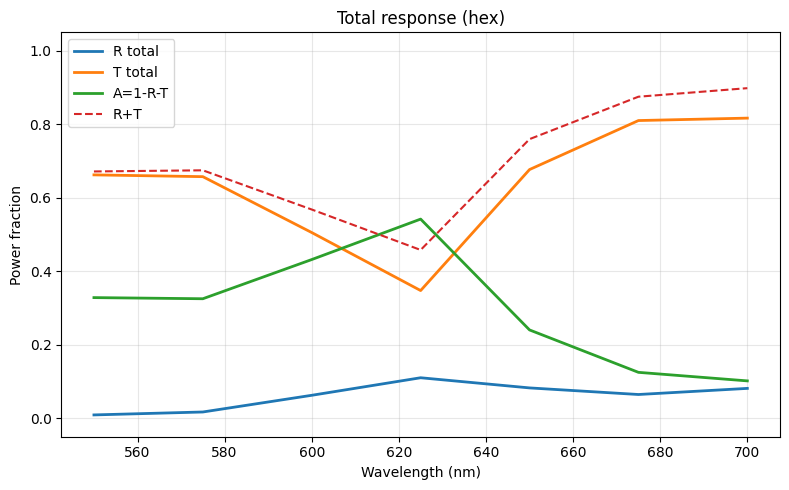

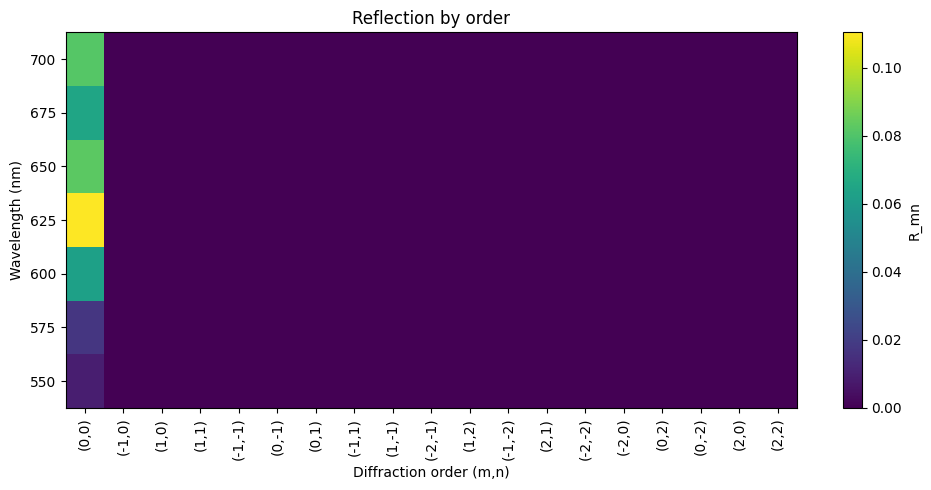

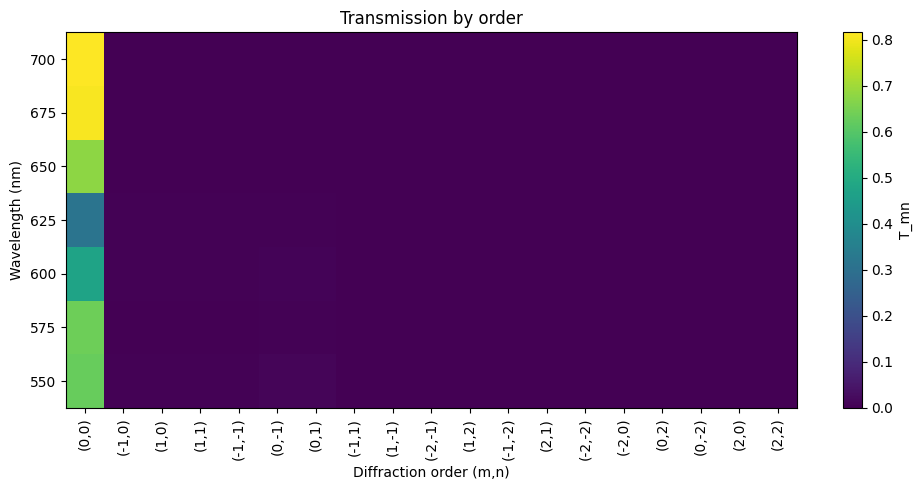

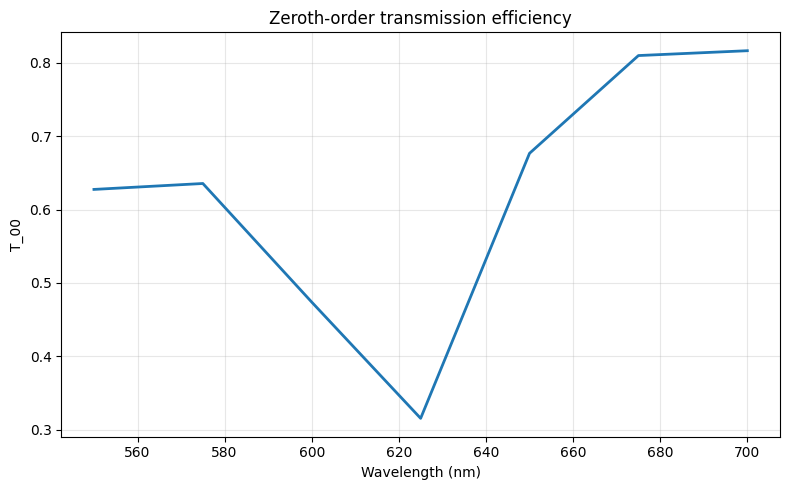

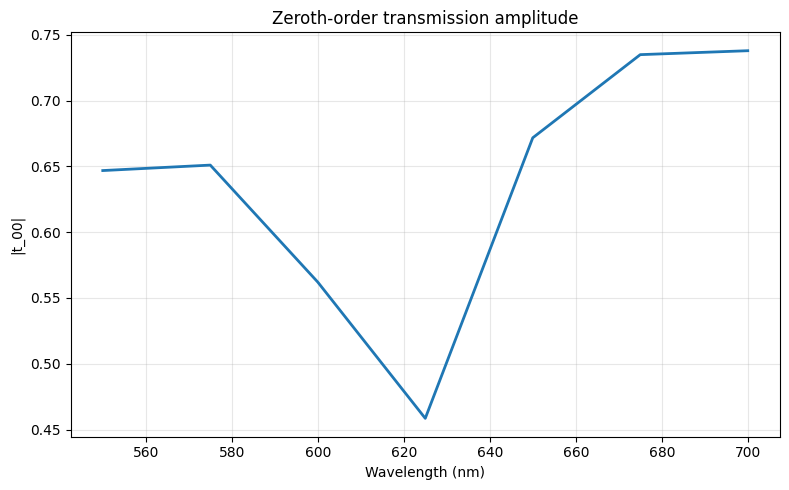

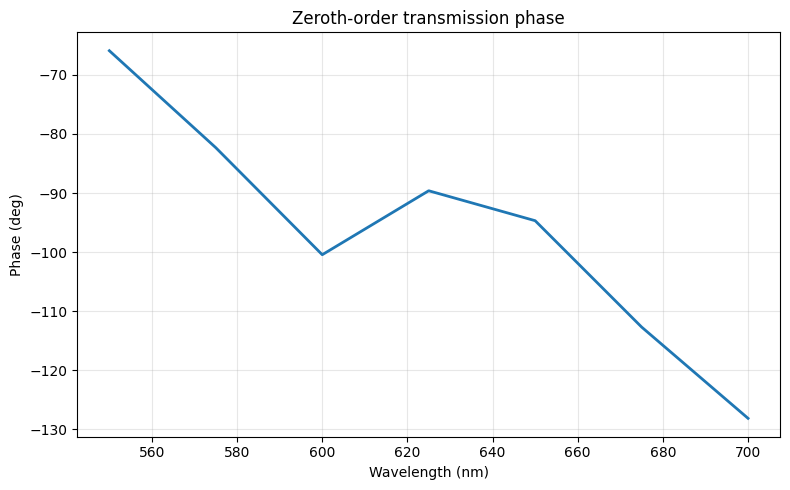

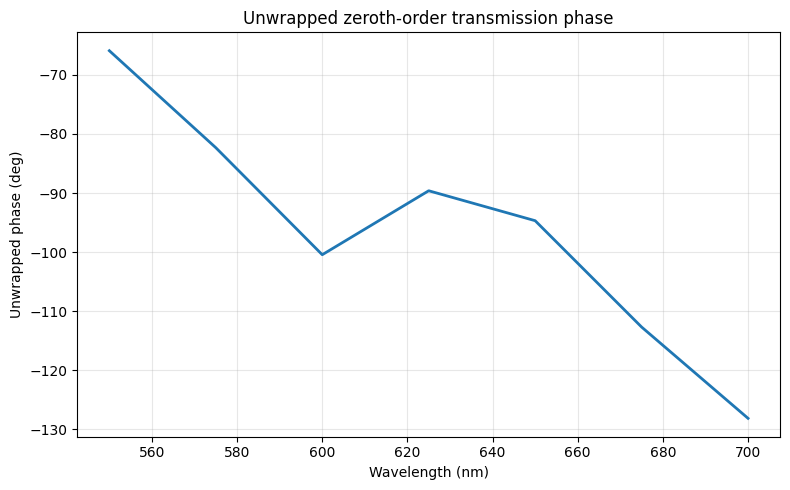

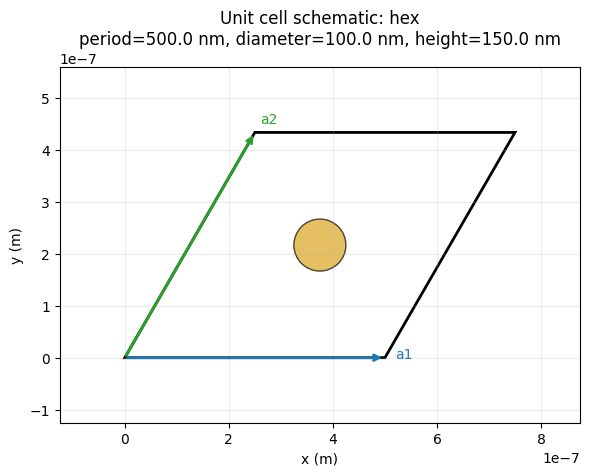

Saved files:
  orders_all_csv: rcwa_current_unit_cell_orders_all.csv
  orders_propagating_csv: rcwa_current_unit_cell_orders_propagating.csv
  totals_csv: rcwa_current_unit_cell_totals.csv
  phase_orders_csv: rcwa_current_unit_cell_orders_phase.csv
  t00_phase_csv: rcwa_current_unit_cell_t00_phase.csv
  fig_totals: rcwa_current_unit_cell_totals.png
  fig_R_by_order: rcwa_current_unit_cell_R_by_order.png
  fig_T_by_order: rcwa_current_unit_cell_T_by_order.png
  fig_T00: rcwa_current_unit_cell_T00_vs_wavelength.png
  fig_t00_amplitude: rcwa_current_unit_cell_t00_amplitude_vs_wavelength.png
  fig_phase00: rcwa_current_unit_cell_phase00_vs_wavelength.png
  fig_phase00_unwrapped: rcwa_current_unit_cell_phase00_unwrapped_vs_wavelength.png
  unit_cell_schematic: rcwa_current_unit_cell_unit_cell_schematic.png

Current unit cell input:
lattice                               hex
period                                0.0
rod_height                            0.0
rod_diameter                       

In [15]:
# FAST and ACCURATE presets
FAST_PRESET = dict(
    wavelength_min=550e-9,
    wavelength_max=700e-9,
    wavelength_step=25e-9,
    harmonics_xy=(5, 5),
    grid_nx=61,
    grid_ny=61,
    out_prefix="rcwa_fast_test",
    )

ACCURATE_PRESET = dict(
    wavelength_min=450e-9,
    wavelength_max=850e-9,
    wavelength_step=5e-9,
    harmonics_xy=(11, 11),
    grid_nx=121,
    grid_ny=121,
    out_prefix="rcwa_accurate",
    )

# Existing call still works and now also returns complex amplitude + phase information.
res_fast = run_unit_cell_from_input(UNIT_CELL_INPUT)

schematic_path = plot_unit_cell_schematic(res_fast["config"], out_prefix=res_fast["config"].out_prefix)
res_fast["files"]["unit_cell_schematic"] = schematic_path

# Example 633 nm diameter sweep across ALL propagating orders.
# Uncomment to generate the order-resolved diameter library.
# sweep_res = sweep_diameter_all_orders(
#     lattice="square",
#     rod_height=150e-9,
#     diameters=np.arange(50e-9, 201e-9, 10e-9),
#     wavelength=633e-9,
#     period=500e-9,
#     out_prefix="rcwa_diameter_sweep_633nm",
# )
# print(sweep_res["table"][['diameter_nm', 'm', 'n', 'T_mn', 'transmission_amplitude', 'transmission_phase_deg', 'transmission_phase_unwrapped_deg_diam']].head().to_string(index=False))

print("Saved files:")
for k, v in res_fast["files"].items():
    print(f"  {k}: {v}")

print("\nCurrent unit cell input:")
print(pd.Series(UNIT_CELL_INPUT).to_string())

print("\nAll propagating diffraction orders at the first wavelength:")
print(
    res_fast["orders_propagating"][[
        "wavelength_nm",
        "m",
        "n",
        "R_mn",
        "T_mn",
        "transmission_amplitude",
        "transmission_phase_deg",
        "transmission_phase_unwrapped_deg",
        "reflection_amplitude",
        "reflection_phase_deg",
        "reflection_phase_unwrapped_deg",
    ]].loc[res_fast["orders_propagating"]["wavelength_nm"] == res_fast["orders_propagating"]["wavelength_nm"].min()].head(12).to_string(index=False)
    )

# Zeroth-order still available as a metalens reference if needed:
# print(res_fast["t00"][["wavelength_nm", "T00", "amplitude_T00", "phase_T00_deg", "phase_T00_unwrapped_deg"]].head().to_string(index=False))